In [1]:
from spidercat.generate import minimum_E_and_V

n, T = 8, 3


num_edges, num_vertices = minimum_E_and_V(n, T)
print(num_edges, num_vertices)

9 6


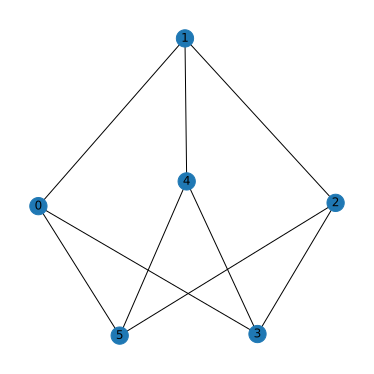

In [2]:
from spidercat.graphs_random import generate_3regular_graph_with_no_nonlocal_t_cut
from spidercat.draw import visualize_cat_state_base, draw_spanning_forest_solution

G = generate_3regular_graph_with_no_nonlocal_t_cut(num_vertices, T)
visualize_cat_state_base(G, [], {})

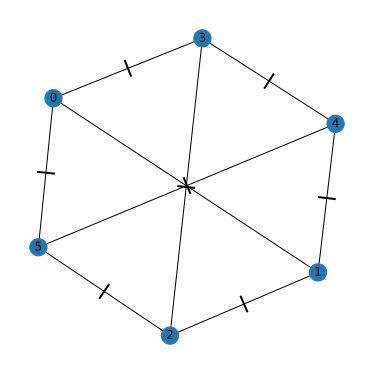

In [3]:
from spidercat.markings import GraphMarker

marker = GraphMarker(G, max_marks=n)
marks = marker.find_solution(3)

visualize_cat_state_base(G, [], marks)

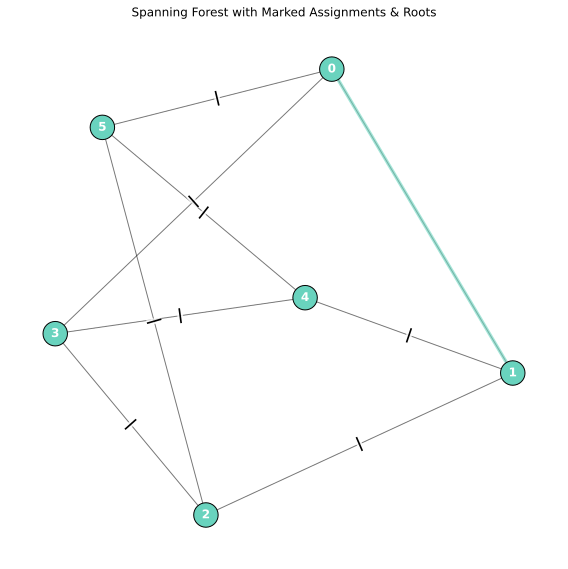

In [4]:
from spidercat.spanning_tree import build_trivial_spanning_forest, build_min_diameter_spanning_tree

forest = build_trivial_spanning_forest(G, marks)
draw_spanning_forest_solution(G, forest, marks, figsize=(8,8))

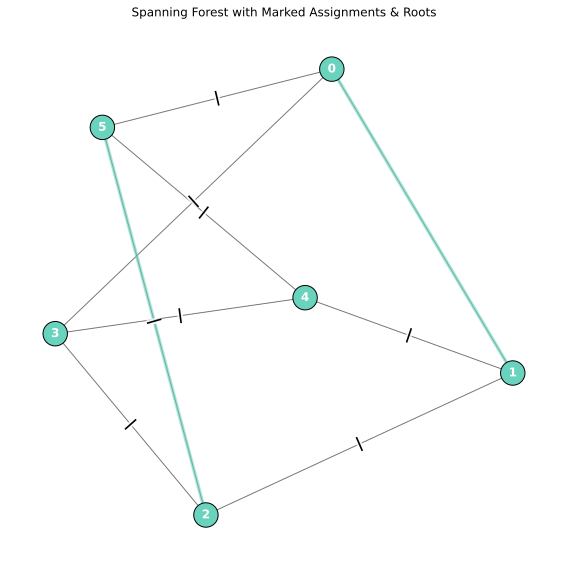

In [5]:
tree = build_min_diameter_spanning_tree(G, forest, marks, 4)
draw_spanning_forest_solution(G, tree, marks, figsize=(8,8))

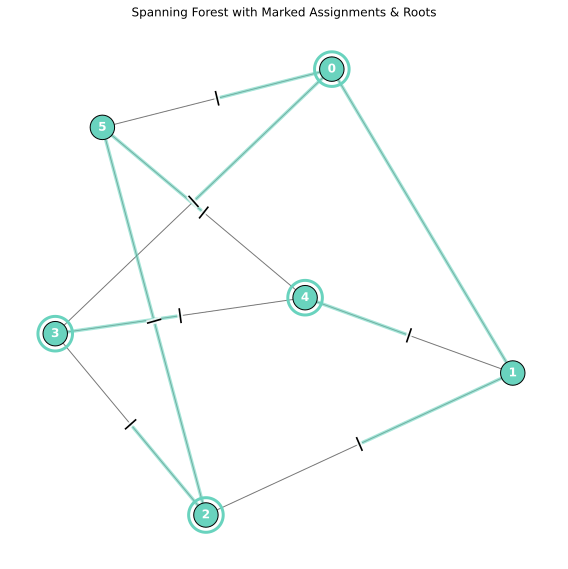

In [6]:
from spidercat.spanning_tree import match_forest_leaves_to_marked_edges, find_min_height_roots

matchings = match_forest_leaves_to_marked_edges(G, tree, marks)
roots = find_min_height_roots(tree)
draw_spanning_forest_solution(G, tree, marks, matchings, roots, figsize=(8,8))

=== Starting Elegant Extraction (BFS) ===
Init Root 0 (Tree 0) -> Q0
Init Root 2 (Tree 2) -> Q1
Init Root 3 (Tree 3) -> Q2
Init Root 4 (Tree 4) -> Q3
  Node 0 -> Branch 1: Spawned CNOT Q0 -> Q4
  Node 0 -> Branch 6: Spawned CNOT Q0 -> Q5
  Node 0 -> Primary 7 (Inherits Q0)
  New flag initialised (2, 8): CNOT Q1 -> Q8
  Node 2 -> Branch 10: Spawned CNOT Q1 -> Q6
  Node 2 -> Primary 11 (Inherits Q1)
  New flag initialised (3, 6): CNOT Q2 -> Q9
  New flag initialised (3, 11): CNOT Q2 -> Q10
  Node 3 -> Primary 12 (Inherits Q2)
  New flag initialised (4, 12): CNOT Q3 -> Q11
  New flag initialised (4, 13): CNOT Q3 -> Q12
  Node 4 -> Primary 9 (Inherits Q3)
  New flag initialised (1, 9): CNOT Q4 -> Q13
  Node 1 -> Primary 8 (Inherits Q4)
  Flag (6, 3) finalised: CNOT Q5 -> Q9; PostSelect_Z 9
  Node 6 serves as a sink point for Q5
  New flag initialised (7, 5): CNOT Q0 -> Q14
  Node 7 serves as a sink point for Q0
  Mark on 10: Spawned CNOT Q6 -> Q7
  Node 10 -> Primary 5 (Inherits Q6)
  Flag

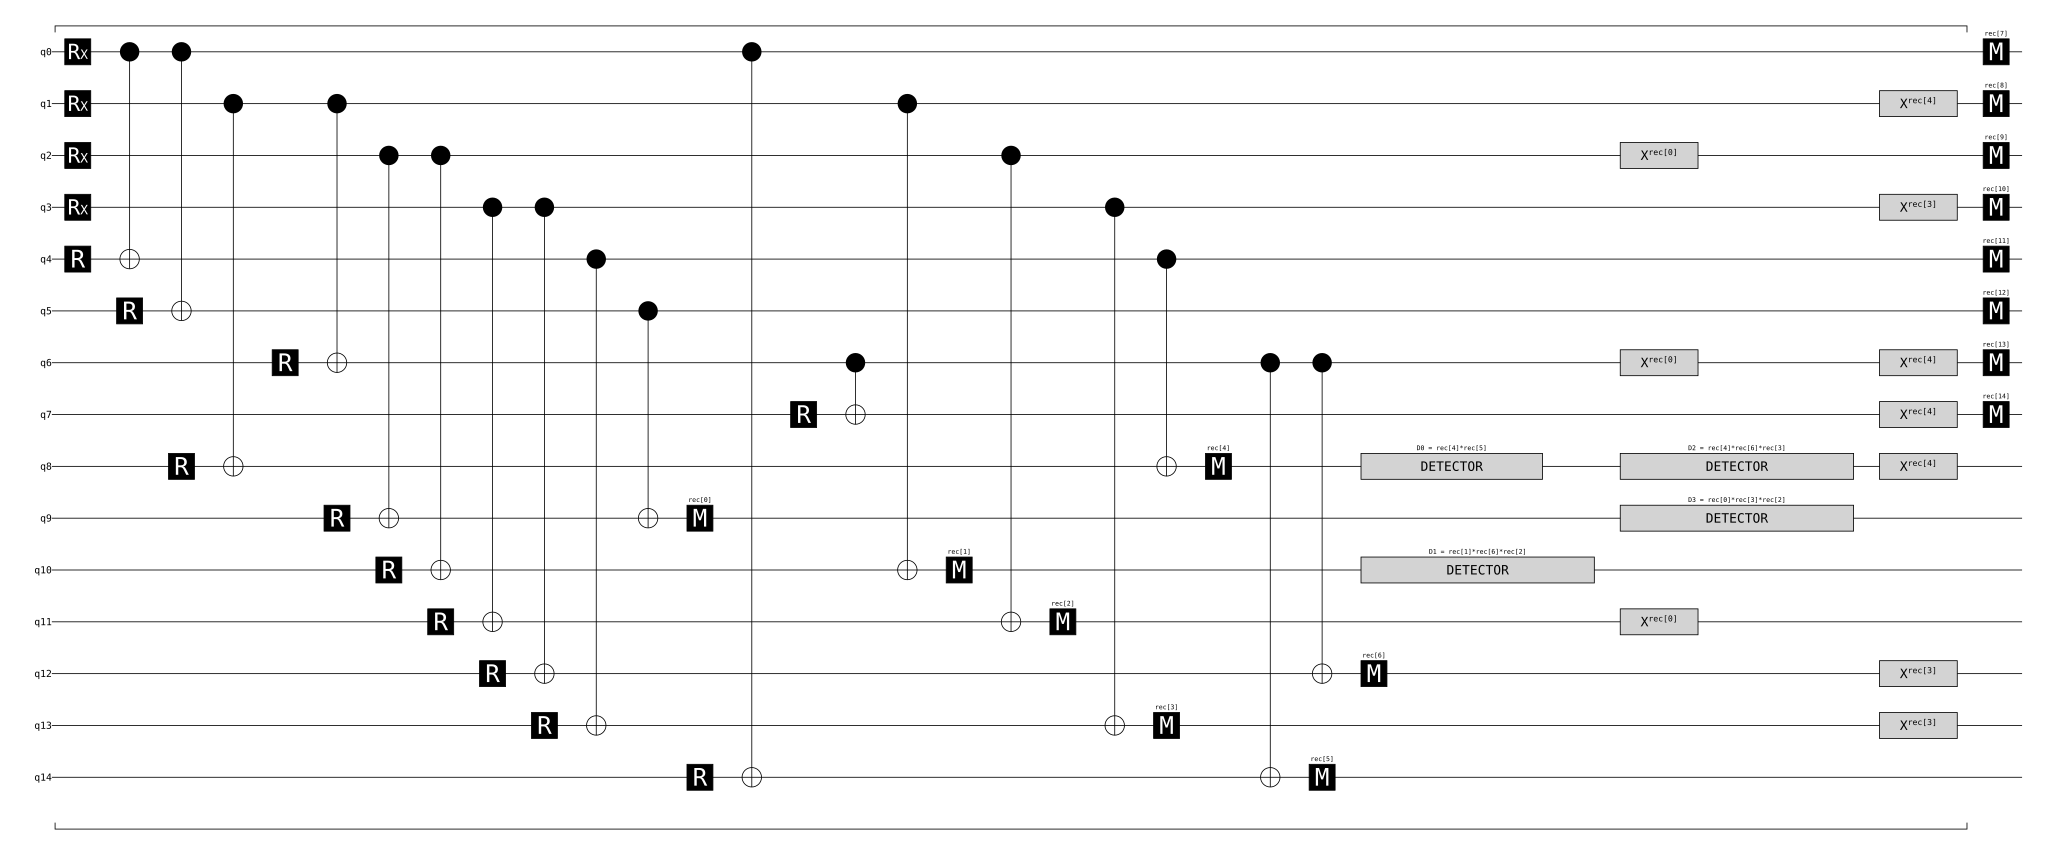

In [7]:
from spidercat.circuit_extraction import extract_circuit_rooted

circ = extract_circuit_rooted(G, tree, roots, marks, matchings, verbose=True)
circ.append("TICK", [])
circ.append("M", range(n))
circ.diagram('timeline-svg')

In [18]:
samples = circ.compile_sampler().sample(10)
converter = circ.compile_m2d_converter()

print(samples[:,-n:].astype(int))
l, d = converter.convert(measurements=samples, separate_observables=True)
print()
print(samples[:,:-n].astype(int))

[[0 0 0 0]
 [0 0 0 0]
 [1 1 1 1]
 [0 0 0 0]
 [1 1 1 1]
 [0 0 0 0]
 [1 1 1 1]
 [1 1 1 1]
 [0 0 0 0]
 [0 0 0 0]]

[[1 1 1 1]
 [0 0 0 0]
 [0 0 0 0]
 [1 1 1 1]
 [1 1 1 1]
 [1 1 1 1]
 [1 1 1 1]
 [0 0 0 0]
 [1 1 1 1]
 [0 0 0 0]]
